In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully!


In [2]:
# Import libraries
import pandas as pd
import numpy as np

# Make random values reproducible
np.random.seed(42)

# Crop names
crops = ["Rice", "Wheat", "Maize"]

# Empty list to store data
data = []

# Generate 1000 records
for i in range(1000):

    rainfall = np.random.randint(50, 251)        # mm
    temperature = np.random.randint(18, 41)      # °C
    humidity = np.random.randint(40, 96)         # %
    fertilizer = np.random.randint(40, 151)      # kg/hectare
    pesticide = np.random.randint(5, 41)         # kg/hectare

    crop = np.random.choice(crops)

    # Calculate yield
    yield_value = (
        rainfall * 0.02 +
        fertilizer * 0.03 +
        humidity * 0.02 -
        temperature * 0.04 -
        pesticide * 0.01 +
        np.random.uniform(-0.5, 0.5)
    )

    data.append([
        rainfall,
        temperature,
        humidity,
        fertilizer,
        pesticide,
        crop,
        round(yield_value, 2)
    ])

# Create DataFrame
df = pd.DataFrame(data, columns=[
    "Rainfall",
    "Temperature",
    "Humidity",
    "Fertilizer",
    "Pesticide",
    "Crop",
    "Yield"
])

# Save dataset
df.to_csv("../data/crop_yield.csv", index=False)

print("Dataset created successfully!")

# Display first five rows
df.head()

Dataset created successfully!


,Rainfall,Temperature,Humidity,Fertilizer,Pesticide,Crop,Yield
0,152,37,68,54,12,Rice,4.52
1,171,36,62,114,15,Rice,6.59
2,201,20,61,92,6,Wheat,6.85
3,241,38,72,115,26,Rice,7.86
4,98,27,67,99,20,Maize,4.95


In [4]:
#load the dataset
df = pd.read_csv("../data/crop_yield.csv")

# show first 5 rows
df.head()

,Rainfall,Temperature,Humidity,Fertilizer,Pesticide,Crop,Yield
0,152,37,68,54,12,Rice,4.52
1,171,36,62,114,15,Rice,6.59
2,201,20,61,92,6,Wheat,6.85
3,241,38,72,115,26,Rice,7.86
4,98,27,67,99,20,Maize,4.95


In [5]:
print("Dataset shape: ", df.shape)

Dataset shape:  (1000, 7)


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Rainfall     1000 non-null   int64  
 1   Temperature  1000 non-null   int64  
 2   Humidity     1000 non-null   int64  
 3   Fertilizer   1000 non-null   int64  
 4   Pesticide    1000 non-null   int64  
 5   Crop         1000 non-null   str    
 6   Yield        1000 non-null   float64
dtypes: float64(1), int64(5), str(1)
memory usage: 54.8 KB


In [7]:
df.describe

<bound method NDFrame.describe of      Rainfall  Temperature  Humidity  Fertilizer  Pesticide   Crop  Yield
0         152           37        68          54         12   Rice   4.52
1         171           36        62         114         15   Rice   6.59
2         201           20        61          92          6  Wheat   6.85
3         241           38        72         115         26   Rice   7.86
4          98           27        67          99         20  Maize   4.95
..        ...          ...       ...         ...        ...    ...    ...
995       123           19        45          47         15  Maize   3.38
996       189           26        41          47         15   Rice   5.05
997       161           25        75         132         16   Rice   7.68
998       231           35        60         125         25  Wheat   7.49
999        69           40        46          48          5  Wheat   2.33

[1000 rows x 7 columns]>

In [8]:
df.isnull().sum()

Rainfall       0
Temperature    0
Humidity       0
Fertilizer     0
Pesticide      0
Crop           0
Yield          0
dtype: int64

In [ ]:
print(df["Crop"].value_counts())

Crop
Rice     360
Maize    327
Wheat    313
Name: count, dtype: int64


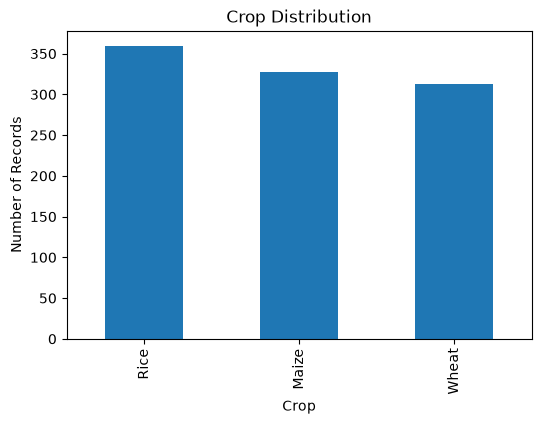

In [13]:
df["Crop"].value_counts().plot(kind="bar", figsize=(6,4))

plt.title("Crop Distribution")
plt.xlabel("Crop")
plt.ylabel("Number of Records")

plt.show()

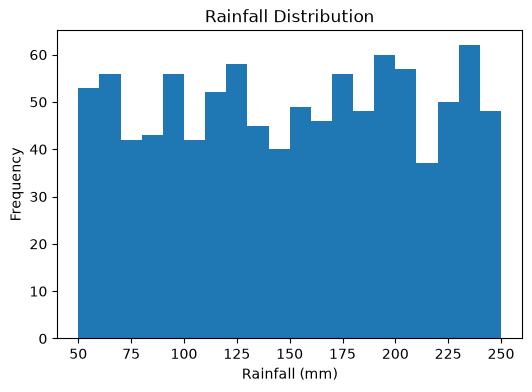

In [15]:
plt.figure(figsize=(6,4))

plt.hist(df["Rainfall"], bins=20)

plt.title("Rainfall Distribution")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")

plt.show()

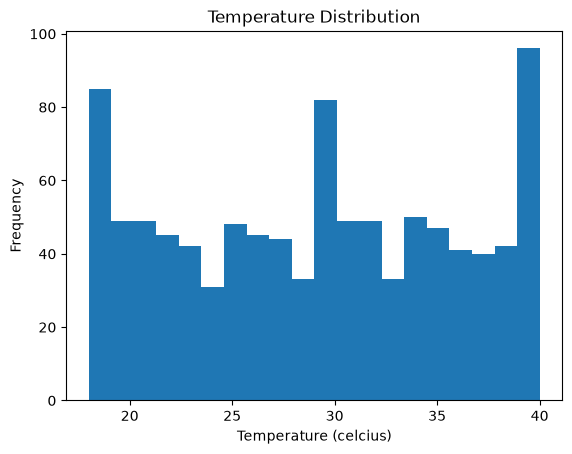

In [16]:
plt.Figure(figsize=(6,4))

plt.hist(df["Temperature"], bins=20)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (celcius)")
plt.ylabel("Frequency")

plt.show()

In [20]:
from sklearn.preprocessing import LabelEncoder

#create encoder
encoder = LabelEncoder()

# convert crop names into numbers
df["Crop"] = encoder.fit_transform(df["Crop"])

#Display first 5 rows 
df.head()

,Rainfall,Temperature,Humidity,Fertilizer,Pesticide,Crop,Yield
0,152,37,68,54,12,1,4.52
1,171,36,62,114,15,1,6.59
2,201,20,61,92,6,2,6.85
3,241,38,72,115,26,1,7.86
4,98,27,67,99,20,0,4.95


In [21]:
#input features
x = df.drop("Yield", axis=1)

#target value
y = df["Yield"]

print(x.head())
print(y.head())

   Rainfall  Temperature  Humidity  Fertilizer  Pesticide  Crop
0       152           37        68          54         12     1
1       171           36        62         114         15     1
2       201           20        61          92          6     2
3       241           38        72         115         26     1
4        98           27        67          99         20     0
0    4.52
1    6.59
2    6.85
3    7.86
4    4.95
Name: Yield, dtype: float64


In [22]:
from sklearn.model_selection import train_test_split

x_train,x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

print("Training Data:", x_train.shape)
print("Testing Data:", x_test.shape)

Training Data: (800, 6)
Testing Data: (200, 6)


In [23]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=200,random_state=42)

model.fit(x_train, y_train)

print("Model trained successfully")

Model trained successfully


In [24]:
y_pred = model.predict(x_test)

print(y_pred[:10])

[6.3008  5.6777  6.7946  4.2557  7.7795  4.55915 5.25455 6.85905 3.8965
 5.4696 ]


In [25]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

print("Mean Absolute Error(MAE):",mean_absolute_error(y_test,y_pred))
print("Mean Squared Error(MSE):",mean_squared_error(y_test,y_pred))
print("R^2 score:", r2_score(y_test,y_pred))

Mean Absolute Error(MAE): 0.32167450000000003
Mean Squared Error(MSE): 0.15004445242500014
R^2 score: 0.9468007826654727


In [26]:
results = pd.DataFrame({
    "Actual Yield": y_test,
    "Predicted Yield": y_pred
})

results.head(10)

,Actual Yield,Predicted Yield
521,6.41,6.30080
737,5.65,5.67770
740,6.22,6.79460
660,4.41,4.25570
411,8.24,7.77950
678,4.48,4.55915
626,6.16,5.25455
513,7.21,6.85905
859,3.54,3.89650
136,5.95,5.46960


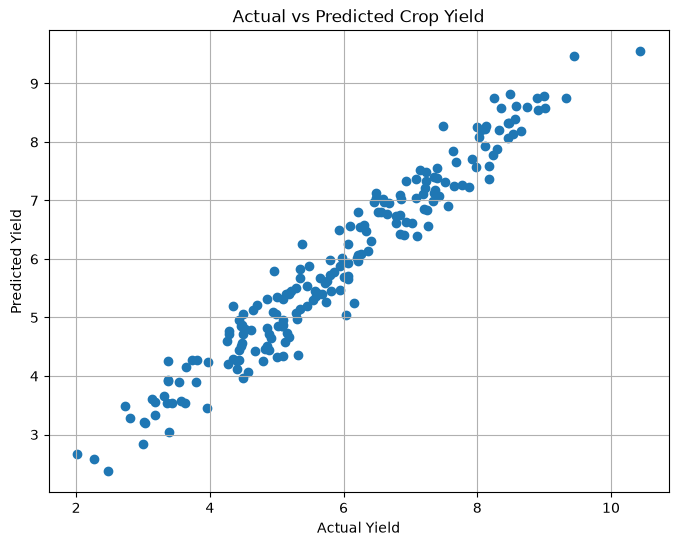

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Crop Yield")

plt.grid(True)

plt.show()

In [30]:

importance = pd.Series(
    model.feature_importances_,
    index=x.columns
)

importance = importance.sort_values(ascending=False)

print(importance)



Rainfall       0.557754
Fertilizer     0.362355
Humidity       0.040396
Temperature    0.027603
Pesticide      0.009274
Crop           0.002618
dtype: float64


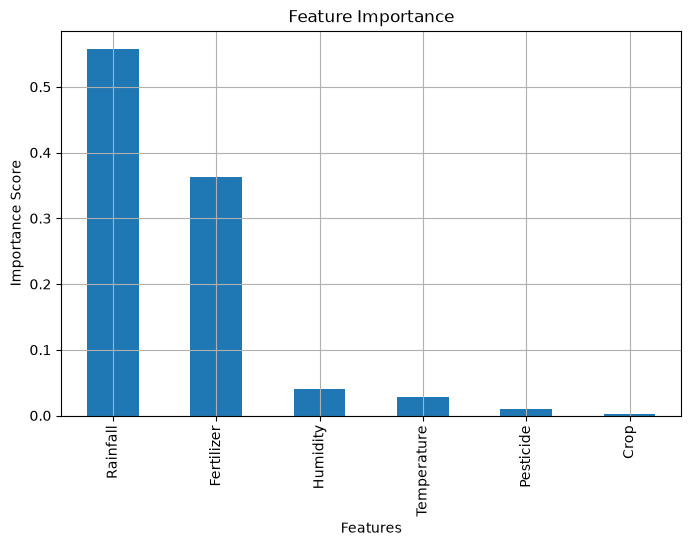

In [31]:
plt.figure(figsize=(8,5))

importance.plot(kind="bar")

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance Score")

plt.grid(True)

plt.show()

In [32]:
import joblib

joblib.dump(model, "../models/crop_yield_model.pkl")

print("Model saved successfully!")


Model saved successfully!


In [33]:
loaded_model = joblib.load("../models/crop_yield_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [34]:
new_data = pd.DataFrame({
    "Rainfall": [150],
    "Temperature": [28],
    "Humidity": [70],
    "Fertilizer": [100],
    "Pesticide": [15],
    "Crop": [1]
})

prediction = loaded_model.predict(new_data)

print(f"Predicted Crop Yield: {prediction[0]:.2f} tons/hectare")

Predicted Crop Yield: 5.89 tons/hectare
